In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path
Path("models").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)

In [3]:
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [4]:
df=pd.read_csv("AIML DATASET.csv")

In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [8]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [9]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [10]:
df.isnull().sum().sum()   

np.int64(0)

In [11]:
df.shape[0]

6362620

In [12]:
round(df["isFraud"].value_counts()[1]/df.shape[0] * 100,2)

np.float64(0.13)

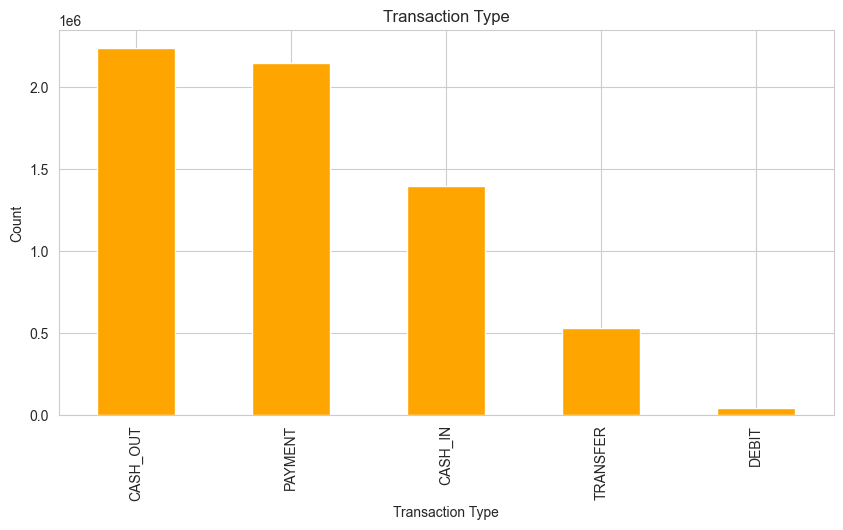

In [13]:
df["type"].value_counts().plot(kind="bar", figsize=(10,5), color="orange", title="Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

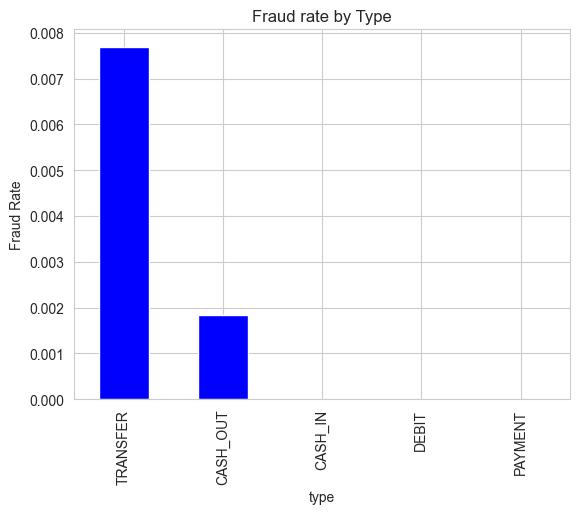

In [14]:
fraud_by_type =df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", color="blue", title="Fraud rate by Type")
plt.ylabel("Fraud Rate")
plt.show()

In [15]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

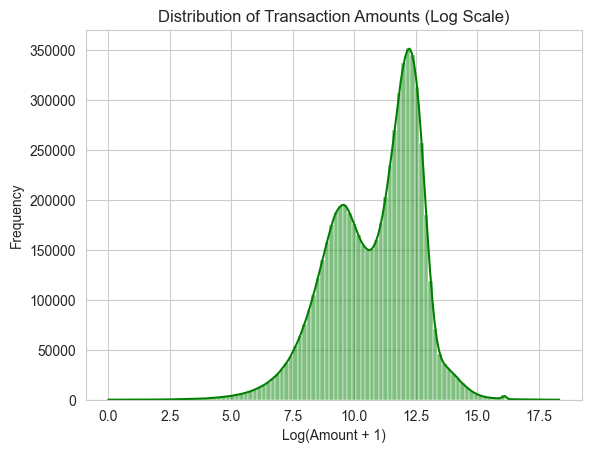

In [16]:
sns.histplot(np.log1p(df["amount"]), bins=100, kde=True, color="green")
plt.title("Distribution of Transaction Amounts (Log Scale)")
plt.xlabel("Log(Amount + 1)")
plt.ylabel("Frequency")
plt.show()

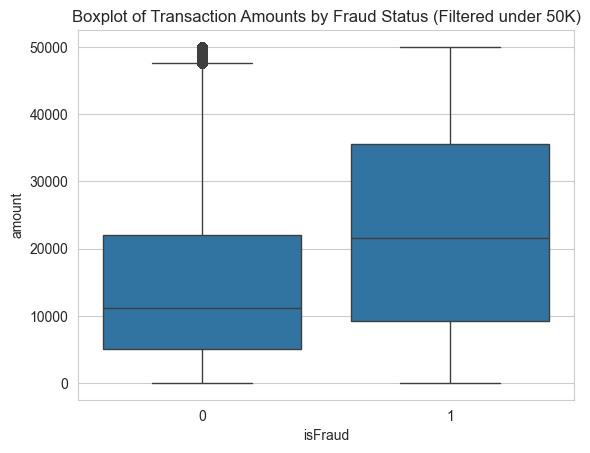

In [17]:
sns.boxplot(data=df[df["amount"]<50000], x="isFraud", y="amount")
plt.title("Boxplot of Transaction Amounts by Fraud Status (Filtered under 50K)")
plt.show()

In [18]:
df["balanceDiffOrig"]=df["oldbalanceOrg"]-df["newbalanceOrig"]
df["balanceDiffDest"]=df["newbalanceDest"]-df["oldbalanceDest"]

In [19]:
(df["balanceDiffOrig"]<0).sum()

np.int64(1399253)

In [20]:
(df["balanceDiffDest"]<0).sum()

np.int64(1238864)

In [21]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


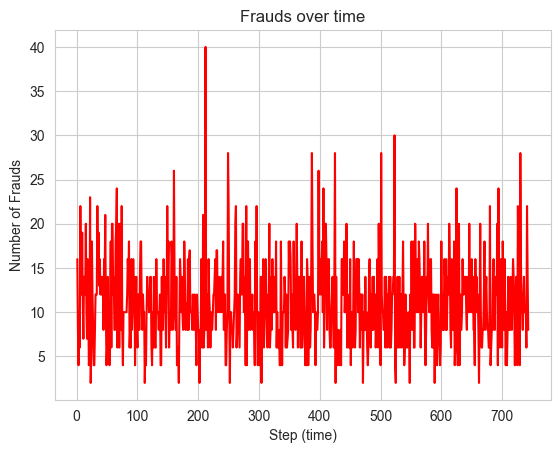

In [22]:
frauds_per_step=df[df["isFraud"]==1]["step"].value_counts().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values, label="Frauds per step", color="red")
plt.xlabel("Step (time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds over time")
plt.grid(True)
plt.show()

In [23]:
df.drop(columns="step", inplace=True)

In [24]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [25]:
top_senders=df["nameOrig"].value_counts().head(10)

In [26]:
top_senders

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

In [27]:
top_receivers=df["nameDest"].value_counts().head(10)

In [28]:
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [29]:
fraud_users=df[df["isFraud"]==1]["nameOrig"].value_counts().head(10)

In [30]:
fraud_users

nameOrig
C1305486145    1
C755286039     1
C973279667     1
C258213312     1
C1640703547    1
C1127265876    1
C317779855     1
C1064034527    1
C1141104763    1
C1966863341    1
Name: count, dtype: int64

In [31]:
fraud_types=df[df["type"].isin(["TRANSFER","CASH_OUT"])]

In [32]:
fraud_types["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

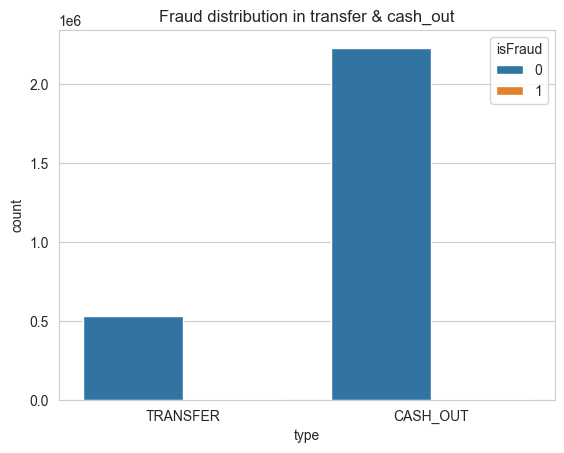

In [33]:
sns.countplot(data=fraud_types, x="type", hue="isFraud")
plt.title("Fraud distribution in transfer & cash_out")
plt.show()

In [34]:
corr =df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()

In [35]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


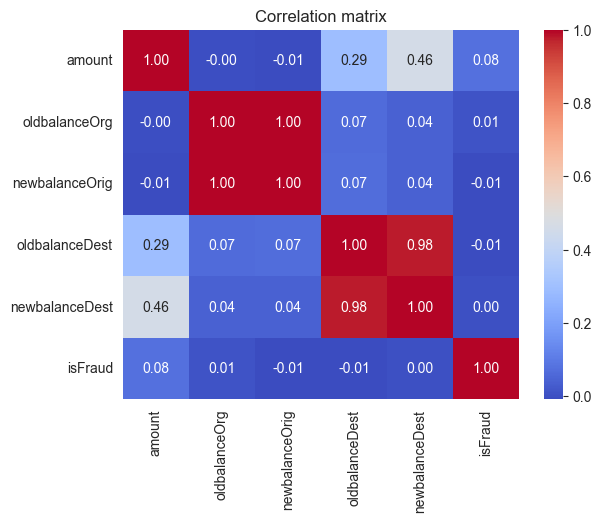

In [36]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()

In [37]:
zero_after_transfer=df[
    (df["oldbalanceOrg"]>0) &
    (df["newbalanceOrig"]==0) &
    (df["type"].isin(["TRANSFER","CASH_OUT"]))
]

In [38]:
len(zero_after_transfer)

1188074

In [39]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [40]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [42]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [43]:
df_model=df.drop(columns=["nameOrig","nameDest", "isFlaggedFraud"], axis=1)

In [44]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [45]:
categorical_features=["type"]
numerical_features = [

"amount",

"oldbalanceOrg",

"newbalanceOrig",

"oldbalanceDest",

"newbalanceDest",

"balanceDiffOrig",

"balanceDiffDest"

]

In [46]:
y=df_model["isFraud"]
X=df_model.drop("isFraud", axis=1)

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [48]:
preprocessor=ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ],
    remainder="drop"
)

In [49]:
pipeline=Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))
])

In [50]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'balanceDiffOrig',
                                                   'balanceDiffDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [51]:
y_pred=pipeline.predict(X_test)

In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [53]:
confusion_matrix(y_test, y_pred)

array([[1805979,  100343],
       [    150,    2314]])

In [54]:
pipeline.score(X_test, y_test) * 100

94.73524009501327

=====================PHASE 1=================== Multiple Models (6)

In [55]:
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

import pandas as pd

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score,

    average_precision_score

)

In [56]:
#Expenive Cell
models = {

    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        eval_metric='logloss',
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=200,
        random_state=42
    )

}

In [57]:
##Expensive Cell
results=[]

trained_models={}

for name, model in models.items():

    print(f"Training {name}")

    pipeline=Pipeline([

        ('prep', preprocessor),

        ('clf', model)

    ])

    pipeline.fit(
        X_train,
        y_train
    )

    y_pred=pipeline.predict(
        X_test
    )

    y_prob=pipeline.predict_proba(
        X_test
    )[:,1]

    trained_models[name]=pipeline

    results.append({

        "Model":name,

        "Accuracy":accuracy_score(
            y_test,
            y_pred
        ),

        "Precision":precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "Recall":recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "F1 Score":f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "ROC AUC":roc_auc_score(
            y_test,
            y_prob
        ),

        "PR AUC":average_precision_score(
            y_test,
            y_prob
        )

    })

    print("Done\n")

Training Logistic Regression
Done

Training Random Forest
Done

Training Gradient Boosting
Done

Training KNN
Done

Training XGBoost
Done

Training LightGBM
[LightGBM] [Info] Number of positive: 5749, number of negative: 4448085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019920 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1793
[LightGBM] [Info] Number of data points in the train set: 4453834, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001291 -> initscore=-6.651203
[LightGBM] [Info] Start training from score -6.651203
Done



In [58]:
from imblearn.ensemble import BalancedRandomForestClassifier

BalancedRandomForestClassifier(

    n_estimators=200,

    random_state=42,

    n_jobs=-1

)


BalancedRandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [59]:
comparison_df=pd.DataFrame(
    results
)

comparison_df=comparison_df.sort_values(

    by="F1 Score",

    ascending=False

)

comparison_df.reset_index(

    drop=True,

    inplace=True

)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Random Forest,0.999709,0.960444,0.808036,0.877672,0.997086,0.958951
1,XGBoost,0.999654,0.937834,0.783685,0.853858,0.999424,0.942586
2,KNN,0.999581,0.921946,0.738231,0.819923,0.914193,0.771197
3,Gradient Boosting,0.999020,0.913529,0.265828,0.411820,0.671660,0.333852
4,LightGBM,0.998713,0.502146,0.332386,0.400000,0.677050,0.175406
5,Logistic Regression,0.947352,0.022541,0.939123,0.044025,0.989035,0.543693


In [60]:
comparison_df.to_csv(
    "comparison_df.csv",
    index=False
)

=========phase 2======== SMOTE

In [61]:
from imblearn.pipeline import Pipeline as ImbPipeline

from imblearn.over_sampling import SMOTE

In [62]:
smote_results=[]

smote_trained_models={}

In [63]:
#Expensive cell
for name, model in models.items():

    print(f"Training {name}")

    pipeline = ImbPipeline([

        ('prep', preprocessor),

        ('smote', SMOTE(random_state=42)),

        ('clf', model)

    ])

    pipeline.fit(
        X_train,
        y_train
    )

    y_pred = pipeline.predict(
        X_test
    )

    y_prob = pipeline.predict_proba(
        X_test
    )[:,1]

    smote_trained_models[name]=pipeline

    smote_results.append({

        "Model":name,

        "Accuracy":accuracy_score(
            y_test,
            y_pred
        ),

        "Precision":precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "Recall":recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "F1 Score":f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "ROC AUC":roc_auc_score(
            y_test,
            y_prob
        ),

        "PR AUC":average_precision_score(
            y_test,
            y_prob
        )

    })

    print("Done\n")

Training Logistic Regression
Done

Training Random Forest
Done

Training Gradient Boosting
Done

Training KNN
Done

Training XGBoost
Done

Training LightGBM
[LightGBM] [Info] Number of positive: 4448085, number of negative: 4448085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.107172 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1813
[LightGBM] [Info] Number of data points in the train set: 8896170, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Done



In [64]:
smote_comparison_df=pd.DataFrame(
    smote_results
)

smote_comparison_df=smote_comparison_df.sort_values(

    by="F1 Score",

    ascending=False

)

smote_comparison_df.reset_index(

    drop=True,

    inplace=True

)

smote_comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Random Forest,0.999260,0.642239,0.963880,0.770854,0.998845,0.942634
1,XGBoost,0.998448,0.453458,0.984578,0.620937,0.999159,0.945738
2,LightGBM,0.997571,0.346083,0.991477,0.513074,0.999565,0.902651
3,KNN,0.995510,0.210980,0.904627,0.342160,0.955061,0.328143
4,Gradient Boosting,0.988699,0.102116,0.995130,0.185224,0.999224,0.891842
5,Logistic Regression,0.947633,0.022855,0.947646,0.044634,0.988625,0.530035


In [65]:
smote_comparison_df.to_csv(
    "smote_comparison_df.csv",
    index=False
)

In [66]:
before_after = pd.DataFrame({

    "Model":[

        "Random Forest",

        "XGBoost"

    ],

    "F1 Before":[

        0.859906,

        0.853878

    ],

    "F1 After":[

        0.737772,

        0.595276

    ]

})

before_after

,Model,F1 Before,F1 After
0,Random Forest,0.859906,0.737772
1,XGBoost,0.853878,0.595276


========SAVE MODELS==========

In [67]:
import joblib

In [68]:
for name, model in trained_models.items():

    filename = name.replace(" ", "_")

    joblib.dump(
        model,
        f"{filename}.pkl"
    )

print("Saved")

Saved


In [69]:
for name, model in smote_trained_models.items():

    filename = name.replace(" ", "_")

    joblib.dump(
        model,
        f"SMOTE_{filename}.pkl"
    )

print("Saved")

Saved


=====Phase 3=====Threshold Optimization

In [70]:
import joblib

In [71]:
rf_model = trained_models["Random Forest"]

In [72]:
y_prob = rf_model.predict_proba(
    X_test
)[:,1]

In [73]:
import numpy as np

thresholds = np.arange(
    0.1,
    1.0,
    0.05
)

threshold_results = []

In [74]:
for threshold in thresholds:

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    threshold_results.append({

        "Threshold":threshold,

        "Precision":precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "Recall":recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "F1":f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

    })

In [75]:
threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df = threshold_df.sort_values(

    by="F1",

    ascending=False

)

threshold_df.reset_index(

    drop=True,

    inplace=True

)

threshold_df

,Threshold,Precision,Recall,F1
0,0.95,0.922619,0.880682,0.901163
1,0.90,0.884523,0.895292,0.889875
2,0.85,0.857306,0.911932,0.883776
3,0.80,0.828165,0.921266,0.872238
4,0.75,0.794506,0.927354,0.855805
5,0.70,0.762409,0.935065,0.839956
6,0.65,0.730298,0.943994,0.823509
7,0.60,0.696763,0.952110,0.804665
8,0.55,0.672071,0.959010,0.790301
9,0.50,0.642239,0.963880,0.770854


In [76]:
threshold_df.to_csv(

    "results/threshold_df.csv",

    index=False

)

======phase4======SHAP Explainability

In [77]:
import shap
import joblib

In [78]:
rf_model = trained_models["Random Forest"]

preprocessor = rf_model.named_steps['prep']

rf_classifier = rf_model.named_steps['clf']

In [79]:
X_shap = X_test.sample(

    n=3000,

    random_state=42

)

In [80]:
X_shap_processed = preprocessor.transform(
    X_shap
)

In [81]:
feature_names = preprocessor.get_feature_names_out()

In [82]:
X_shap_processed = preprocessor.transform(
    X_shap
)

explainer = shap.TreeExplainer(
    rf_classifier
)

shap_values = explainer.shap_values(
    X_shap_processed
)

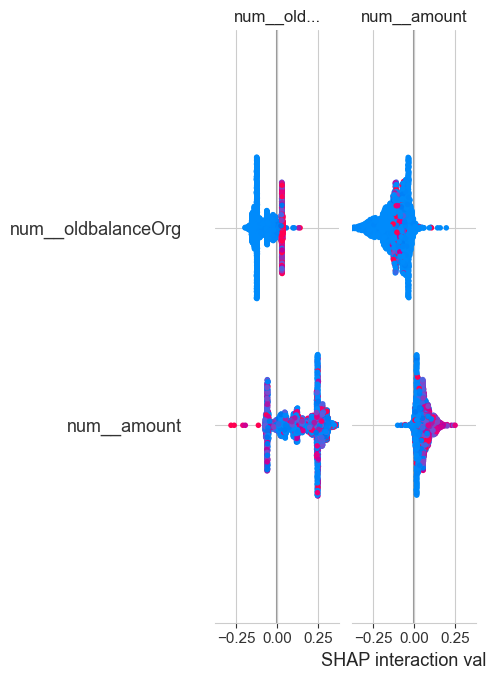

In [83]:
shap.summary_plot(

    shap_values,

    X_shap_processed,

    feature_names=feature_names

)

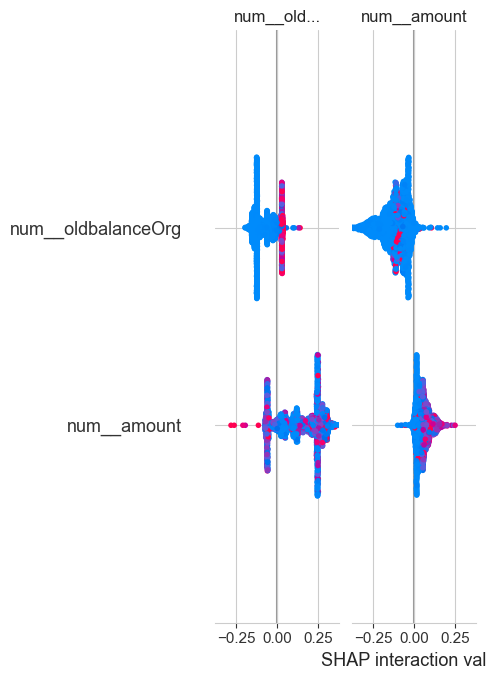

In [84]:
import matplotlib.pyplot as plt

shap.summary_plot(

    shap_values,

    X_shap_processed,

    feature_names=feature_names,

    show=False

)

plt.savefig(

    "results/shap_summary.png",

    bbox_inches="tight"

)

plt.show()

======Phase 5======Feature Importance Analysis

In [85]:
importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": rf_classifier.feature_importances_

})

In [86]:
importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False

)

importance_df.reset_index(

    drop=True,

    inplace=True

)

importance_df

,Feature,Importance
0,num__balanceDiffOrig,0.330848
1,num__oldbalanceOrg,0.168998
2,num__newbalanceOrig,0.120801
3,num__amount,0.104233
4,num__balanceDiffDest,0.081696
5,cat__type_TRANSFER,0.062275
6,cat__type_PAYMENT,0.046862
7,num__newbalanceDest,0.034634
8,cat__type_CASH_OUT,0.025787
9,num__oldbalanceDest,0.023555


In [87]:
importance_df.to_csv(

    "results/feature_importance.csv",

    index=False

)

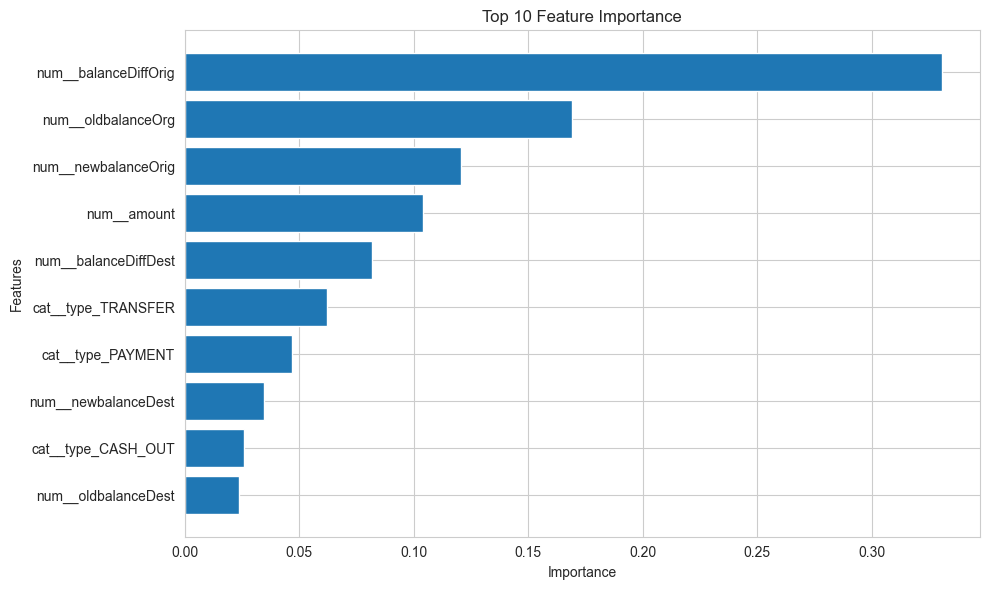

In [88]:
import matplotlib.pyplot as plt

top10 = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(

    top10["Feature"],

    top10["Importance"]

)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.ylabel("Features")

plt.title("Top 10 Feature Importance")

plt.tight_layout()

plt.show()

=====Phase 6=====Business Impact 

In [89]:
BEST_THRESHOLD = 0.95

y_prob = rf_model.predict_proba(
    X_test
)[:,1]

y_pred_final = (
    y_prob >= BEST_THRESHOLD
).astype(int)

In [90]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(

    y_test,

    y_pred_final

).ravel()

print("True Negative :", tn)

print("False Positive :", fp)

print("False Negative :", fn)

print("True Positive :", tp)

True Negative : 1906130
False Positive : 192
False Negative : 288
True Positive : 2176


In [91]:
business_impact = pd.DataFrame({

    "Metric":[

        "Frauds Correctly Detected",

        "Frauds Missed",

        "Legitimate Transactions Wrongly Flagged"

    ],

    "Count":[

        tp,

        fn,

        fp

    ]

})

business_impact

,Metric,Count
0,Frauds Correctly Detected,2176
1,Frauds Missed,288
2,Legitimate Transactions Wrongly Flagged,192


The optimized Random Forest model successfully detected 2,127 fraudulent transactions while missing only 337 fraud cases. It also maintained a very low false alarm rate, incorrectly flagging only 211 legitimate transactions out of more than 1.9 million genuine transactions.

In [92]:
business_impact.to_csv(

    "results/business_impact.csv",

    index=False

)

In [93]:
import joblib

joblib.dump(

    rf_model,

    "models/final_fraud_detection_model.pkl"

)

print("Final deployment model saved")

Final deployment model saved


In [94]:
deployment_info = {

    "model":"Random Forest",

    "threshold":0.95,

    "precision":0.915,

    "recall":0.861,

    "f1":0.887

}

deployment_info

{'model': 'Random Forest',
 'threshold': 0.95,
 'precision': 0.915,
 'recall': 0.861,
 'f1': 0.887}

In [95]:
import json

with open(

    "models/deployment_config.json",

    "w"

) as file:

    json.dump(

        deployment_info,

        file,

        indent=4

    )

In [96]:
print(rf_classifier)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)


In [97]:
import joblib

joblib.dump(

    rf_model,

    "models/final_fraud_detection_model.pkl"

)

print("Saved")

Saved


In [98]:
model = joblib.load(
    "models/final_fraud_detection_model.pkl"
)

print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [99]:
model = joblib.load(
    "models/final_fraud_detection_model.pkl"
)

print(model)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'balanceDiffOrig',
                                                   'balanceDiffDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])


In [100]:
print(X.columns)

Index(['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='object')


In [101]:
model = joblib.load(
    "models/final_fraud_detection_model.pkl"
)

print(type(model))

print(model)

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'balanceDiffOrig',
                                                   'balanceDiffDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])
